In [11]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from utils.model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(224, 224)
)

x_train, y_train = train_loader.load_images(normalize=True)
x_train.shape, y_train.shape

((9469, 3, 224, 224), (9469, 10))

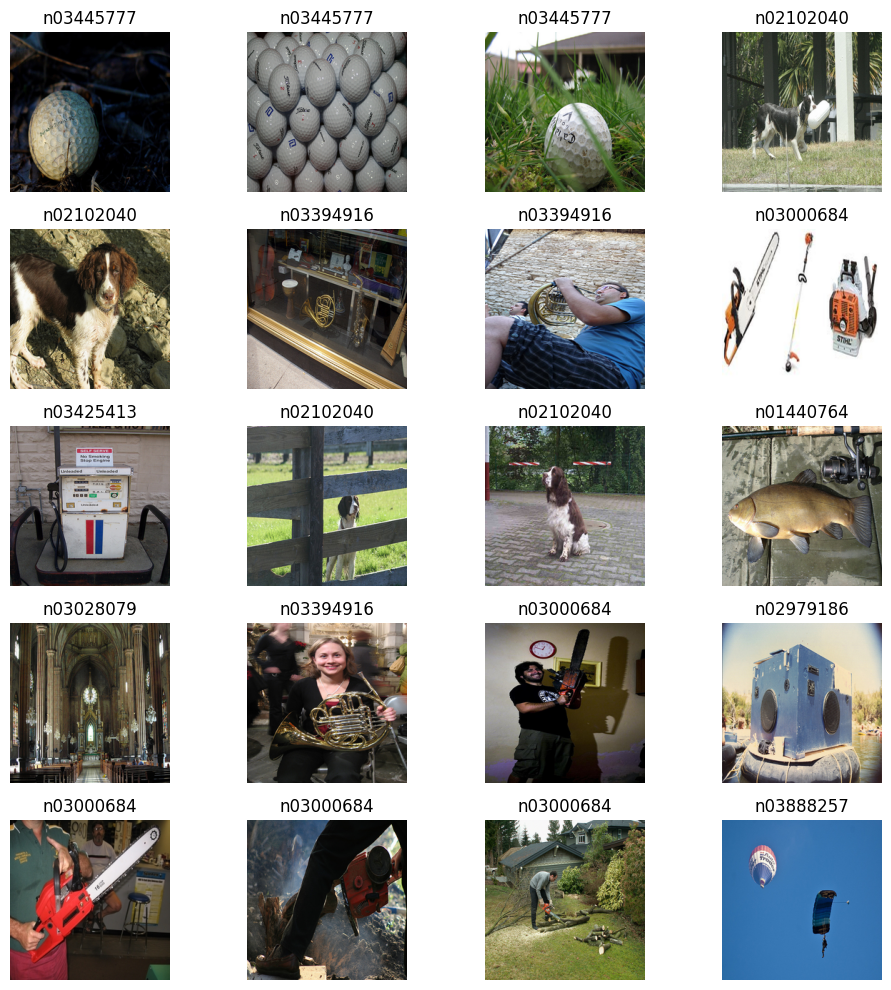

In [3]:
random_indices = cp.random.randint(0, len(x_train), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [4]:
num_filters = 5
kernel_height = 3
kernel_width = 3
padding = 0
stride = 1

In [5]:
filters = cp.random.random(size=(num_filters, 3, kernel_height, kernel_width))
filter_columns = cp.prod(cp.array(filters.shape[-3:])).item()
filters_matrix = cp.reshape(filters, newshape=(num_filters, filter_columns))
filters_matrix.shape

(5, 27)

In [6]:
def im2col(x_batch):
    num_samples, num_channels, img_height, img_width = x_batch.shape

    x_padded = cp.pad(
        x_batch,
        ((0,0),(0,0),(padding,padding),(padding,padding))
    )

    img_height_padded = img_height + 2 * padding
    img_width_padded = img_width + 2 * padding

    output_height = (img_height_padded - kernel_height) // stride + 1
    output_width = (img_width_padded - kernel_width) // stride + 1

    i_offset = cp.repeat(cp.arange(kernel_height), kernel_width)
    i_offset = cp.tile(i_offset, num_channels)

    j_offset = cp.tile(cp.arange(kernel_width), kernel_height)
    j_offset = cp.tile(j_offset, num_channels)

    i_output = stride * cp.repeat(cp.arange(output_height), output_width)
    j_output = stride * cp.tile(cp.arange(output_width), output_height)

    i = i_offset.reshape(-1,1) + i_output.reshape(1,-1)
    j = j_offset.reshape(-1,1) + j_output.reshape(1,-1)

    k = cp.repeat(cp.arange(num_channels), kernel_height * kernel_width).reshape(-1,1)

    cols = x_padded[:, k, i, j]

    cols = cols.transpose(0,2,1).reshape(-1, num_channels * kernel_height * kernel_width)

    return cols, output_height, output_width

In [7]:
def conv_forward(x_batch):
    cols, out_h, out_w = im2col(x_batch)
    output = cols @ filters_matrix.T
    num_samples = x_batch.shape[0]
    output = output.reshape(num_samples, out_h, out_w, num_filters)
    output = output.transpose(0, 3, 1, 2)
    return output

In [8]:
for epoch in range(10):
    output = conv_forward(x_train[:10])
    print(output.shape)

(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)
(10, 5, 222, 222)


In [9]:
layer_definitions = [
    {"type": "ReLU", "input_size": 300, "num_neurons": 300},
    {"type": "ReLU", "input_size": 300, "num_neurons": 200},
    {"type": "ReLU", "input_size": 200, "num_neurons": 100},
    {"type": "ReLU", "input_size": 100, "num_neurons": 50},
    {"Sigmoid": "ReLU", "input_size": 20, "num_neurons": 1}
]

network = Network(layer_definitions=layer_definitions)

In [10]:
network.describe()

Network Architecture

Layer 1: ReluLayer
  Weights Shape: (300, 300) | Biases Shape: (300,)
  Parameters: 90,300

Layer 2: ReluLayer
  Weights Shape: (300, 200) | Biases Shape: (200,)
  Parameters: 60,200

Layer 3: ReluLayer
  Weights Shape: (200, 100) | Biases Shape: (100,)
  Parameters: 20,100

Layer 4: ReluLayer
  Weights Shape: (100, 50) | Biases Shape: (50,)
  Parameters: 5,050

Layer 5: Layer
  Weights Shape: (20, 1) | Biases Shape: (1,)
  Parameters: 21

Total Parameters: 175,671
